In [1]:
# Import libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler

In [2]:
# Load raw Airbnb dataset

df = pd.read_csv(
    "../data/raw/listings.csv"
)

print("Dataset loaded successfully")
print(df.shape)

Dataset loaded successfully
(92638, 90)


In [3]:
# Convert price from string to numerical format

df["price_clean"] = (
    df["price"]
    .str.replace("$", "", regex=False)
    .str.replace(",", "", regex=False)
    .astype(float)
)

df["price_clean"].head()

0    234.50
1    127.00
2    137.50
3    606.67
4     68.30
Name: price_clean, dtype: float64

In [4]:
# Remove listings with missing or zero price

before_rows = df.shape[0]

df = df[
    (df["price_clean"].notnull()) &
    (df["price_clean"] > 0)
]

after_rows = df.shape[0]

print("Rows before cleaning:", before_rows)
print("Rows after cleaning:", after_rows)
print("Removed rows:", before_rows - after_rows)

Rows before cleaning: 92638
Rows after cleaning: 62240
Removed rows: 30398


In [5]:
# Verify price quality after cleaning

print("Missing prices:", df["price_clean"].isnull().sum())
print("Zero prices:", (df["price_clean"] <= 0).sum())

Missing prices: 0
Zero prices: 0


In [6]:
# Calculate 99th percentile price

price_cap = df["price_clean"].quantile(0.99)

print("99th percentile price:", price_cap)

99th percentile price: 1373.4575000000004


In [7]:
# Cap extreme prices at 99th percentile

df["price_capped"] = np.where(
    df["price_clean"] > price_cap,
    price_cap,
    df["price_clean"]
)

df[["price_clean", "price_capped"]].describe()

,price_clean,price_capped
count,62240.000000,62240.000000
mean,271.469220,244.360527
std,2190.599006,225.066039
min,2.230000,2.230000
25%,100.000000,100.000000
50%,180.000000,180.000000
75%,300.032500,300.032500
max,527524.000000,1373.457500


In [8]:
# Log transformation of target variable

df["log_price"] = np.log1p(
    df["price_capped"]
)

df["log_price"].describe()

count    62240.000000
mean         5.188608
std          0.785578
min          1.172482
25%          4.615121
50%          5.198497
75%          5.707218
max          7.225814
Name: log_price, dtype: float64

In [9]:
# Display all columns

df.columns.tolist()

['id',
 'listing_url',
 'scrape_id',
 'last_scraped',
 'source',
 'name',
 'description',
 'neighborhood_overview',
 'picture_url',
 'host_id',
 'host_url',
 'host_profile_id',
 'host_profile_url',
 'host_name',
 'host_since',
 'hosts_time_as_user_years',
 'hosts_time_as_user_months',
 'hosts_time_as_host_years',
 'hosts_time_as_host_months',
 'host_location',
 'host_about',
 'host_response_time',
 'host_response_rate',
 'host_acceptance_rate',
 'host_is_superhost',
 'host_thumbnail_url',
 'host_picture_url',
 'host_neighbourhood',
 'host_listings_count',
 'host_total_listings_count',
 'host_verifications',
 'host_has_profile_pic',
 'host_identity_verified',
 'neighbourhood',
 'neighbourhood_cleansed',
 'neighbourhood_group_cleansed',
 'latitude',
 'longitude',
 'property_type',
 'room_type',
 'accommodates',
 'bathrooms',
 'bathrooms_text',
 'bedrooms',
 'beds',
 'amenities',
 'price',
 'price_quote_checkin_date',
 'price_quote_checkout_date',
 'price_quote_total_price',
 'price_quote

In [10]:
# Remove unnecessary columns

drop_columns = [
    "id",
    "listing_url",
    "scrape_id",
    "last_scraped",
    "source",
    "name",
    "description",
    "neighborhood_overview",
    "picture_url",
    "host_id",
    "host_url",
    "host_profile_id",
    "host_profile_url",
    "host_name",
    "host_about",
    "host_since",
    "host_response_time",
    "host_response_rate",
    "host_acceptance_rate",
    "license"
]

df = df.drop(
    columns=drop_columns,
    errors="ignore"
)

print("Remaining columns:", df.shape[1])

Remaining columns: 73


In [11]:
df["amenities"].head()

0    ["Carbon monoxide alarm", "Portable air condit...
1    ["Babysitter recommendations", "Coffee maker: ...
2    ["Refrigerator", "Long term stays allowed", "C...
3    ["Drying rack for clothing", "Dishwasher", "Lo...
4    ["Oven", "City skyline view", "Toaster", "Priv...
Name: amenities, dtype: str

In [13]:
import ast

In [14]:
# Convert amenities string to Python list

df["amenities_list"] = df["amenities"].apply(
    ast.literal_eval
)

df["amenities_list"].head()

0    [Carbon monoxide alarm, Portable air condition...
1    [Babysitter recommendations, Coffee maker: dri...
2    [Refrigerator, Long term stays allowed, Coffee...
3    [Drying rack for clothing, Dishwasher, Long te...
4    [Oven, City skyline view, Toaster, Private pat...
Name: amenities_list, dtype: object

In [15]:
from collections import Counter

amenity_counter = Counter(
    item
    for amenities in df["amenities_list"]
    for item in amenities
)

top_amenities = (
    amenity_counter
    .most_common(15)
)

top_amenities

[('Wifi', 58108),
 ('Smoke alarm', 57717),
 ('Kitchen', 54776),
 ('Hot water', 49200),
 ('Carbon monoxide alarm', 46349),
 ('Iron', 45117),
 ('Bed linens', 44351),
 ('Hair dryer', 44307),
 ('Hangers', 44289),
 ('Washer', 43293),
 ('Dishes and silverware', 42034),
 ('Refrigerator', 40352),
 ('Cooking basics', 39503),
 ('Hot water kettle', 39409),
 ('TV', 39316)]

In [16]:
# Extract top 15 amenities as binary features

top_amenity_names = [
    item[0] for item in top_amenities
]


for amenity in top_amenity_names:
    column_name = (
        "has_" +
        amenity.lower()
        .replace(" ", "_")
        .replace("-", "_")
    )
    
    df[column_name] = df["amenities_list"].apply(
        lambda x: 1 if amenity in x else 0
    )


df.head()

,hosts_time_as_user_years,hosts_time_as_user_months,hosts_time_as_host_years,hosts_time_as_host_months,host_location,host_is_superhost,host_thumbnail_url,host_picture_url,host_neighbourhood,host_listings_count,...,has_iron,has_bed_linens,has_hair_dryer,has_hangers,has_washer,has_dishes_and_silverware,has_refrigerator,has_cooking_basics,has_hot_water_kettle,has_tv
0,16.0,8.0,15.0,5.0,"London, United Kingdom",t,NaN,https://a0.muscache.com/im/pictures/user/User/...,NaN,1.0,...,1,1,1,1,0,1,1,1,1,0
1,16.0,7.0,15.0,5.0,"London, United Kingdom",f,NaN,https://a0.muscache.com/im/users/54730/profile...,NaN,2.0,...,1,1,1,1,0,1,1,1,1,0
2,16.0,6.0,15.0,5.0,"Royal Borough of Kensington and Chelsea, Unite...",f,NaN,https://a0.muscache.com/im/users/60302/profile...,NaN,1.0,...,1,0,1,1,1,1,1,1,0,0
3,16.0,5.0,15.0,5.0,"London, United Kingdom",t,NaN,https://a0.muscache.com/im/users/67564/profile...,NaN,3.0,...,1,1,1,1,0,1,1,1,1,1
4,14.0,0.0,14.0,0.0,"London, United Kingdom",f,NaN,https://a0.muscache.com/im/users/2528030/profi...,NaN,2.0,...,0,0,0,0,0,1,1,1,0,0


In [17]:
# Remove original amenities columns

df = df.drop(
    columns=[
        "amenities",
        "amenities_list"
    ],
    errors="ignore"
)

print(df.shape)

(62240, 87)


In [18]:
# Check top neighbourhood categories

df["neighbourhood_cleansed"].value_counts().head(20)

neighbourhood_cleansed
Westminster               8257
Kensington and Chelsea    4569
Camden                    4440
Tower Hamlets             4069
Southwark                 3163
Lambeth                   2954
Wandsworth                2925
Hackney                   2922
Hammersmith and Fulham    2763
Islington                 2704
Brent                     2125
Barnet                    1800
Newham                    1776
Ealing                    1707
Lewisham                  1570
Haringey                  1542
Croydon                   1336
Greenwich                 1323
Waltham Forest            1180
Merton                    1093
Name: count, dtype: int64

In [19]:
# Count unique neighbourhoods

print(
    "Total neighbourhood categories:",
    df["neighbourhood_cleansed"].nunique()
)

Total neighbourhood categories: 33


In [20]:
# Select top 15 neighbourhoods

top_neighbourhoods = (
    df["neighbourhood_cleansed"]
    .value_counts()
    .head(15)
    .index
)

top_neighbourhoods

Index(['Westminster', 'Kensington and Chelsea', 'Camden', 'Tower Hamlets',
       'Southwark', 'Lambeth', 'Wandsworth', 'Hackney',
       'Hammersmith and Fulham', 'Islington', 'Brent', 'Barnet', 'Newham',
       'Ealing', 'Lewisham'],
      dtype='str', name='neighbourhood_cleansed')

In [21]:
# Group rare neighbourhoods into Other

df["neighbourhood_grouped"] = np.where(
    df["neighbourhood_cleansed"].isin(top_neighbourhoods),
    df["neighbourhood_cleansed"],
    "Other"
)


df["neighbourhood_grouped"].value_counts()

neighbourhood_grouped
Other                     14496
Westminster                8257
Kensington and Chelsea     4569
Camden                     4440
Tower Hamlets              4069
Southwark                  3163
Lambeth                    2954
Wandsworth                 2925
Hackney                    2922
Hammersmith and Fulham     2763
Islington                  2704
Brent                      2125
Barnet                     1800
Newham                     1776
Ealing                     1707
Lewisham                   1570
Name: count, dtype: int64

In [22]:
df = df.drop(
    columns=["neighbourhood_cleansed"],
    errors="ignore"
)

print(df.shape)

(62240, 87)


In [23]:
# Check remaining missing values

missing_after_cleaning = (
    df.isnull()
    .sum()
    .sort_values(ascending=False)
)

missing_after_cleaning.head(20)

host_thumbnail_url              62240
host_total_listings_count       62240
neighbourhood_group_cleansed    62240
host_verifications              62240
neighbourhood                   62240
host_neighbourhood              62240
calendar_updated                62240
instant_bookable                62240
host_location                   18107
bedrooms                        13738
review_scores_checkin           13574
review_scores_location          13574
review_scores_value             13573
review_scores_accuracy          13572
review_scores_cleanliness       13572
review_scores_communication     13572
last_review                     13570
review_scores_rating            13570
first_review                    13570
reviews_per_month               13570
dtype: int64

In [24]:
# Remove columns with all missing values

empty_columns = [
    col for col in df.columns
    if df[col].isnull().all()
]

print("Completely empty columns:")
print(empty_columns)

df = df.drop(
    columns=empty_columns
)

print("New shape:", df.shape)

Completely empty columns:
['host_thumbnail_url', 'host_neighbourhood', 'host_total_listings_count', 'host_verifications', 'neighbourhood', 'neighbourhood_group_cleansed', 'calendar_updated', 'instant_bookable']
New shape: (62240, 79)


In [25]:
# Identify column types

numeric_columns = df.select_dtypes(
    include=["int64","float64"]
).columns


categorical_columns = df.select_dtypes(
    include=["object"]
).columns


print("Numerical columns:", len(numeric_columns))
print("Categorical columns:", len(categorical_columns))

Numerical columns: 62
Categorical columns: 17


C:\Users\Saptarshi Barman\AppData\Local\Temp\ipykernel_15816\2807560889.py:8: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = df.select_dtypes(


In [26]:
# Fill numerical missing values with median

for col in numeric_columns:
    df[col] = df[col].fillna(
        df[col].median()
    )


print(
    "Remaining numerical missing:",
    df[numeric_columns].isnull().sum().sum()
)

Remaining numerical missing: 0


In [27]:
# Fill categorical missing values

for col in categorical_columns:
    df[col] = df[col].fillna(
        "Unknown"
    )


print(
    "Remaining categorical missing:",
    df[categorical_columns].isnull().sum().sum()
)

Remaining categorical missing: 0


In [28]:
categorical_columns = df.select_dtypes(
    include=["object"]
).columns

categorical_columns

C:\Users\Saptarshi Barman\AppData\Local\Temp\ipykernel_15816\2213581602.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = df.select_dtypes(


Index(['host_location', 'host_is_superhost', 'host_picture_url',
       'host_has_profile_pic', 'host_identity_verified', 'property_type',
       'room_type', 'bathrooms_text', 'price', 'price_quote_checkin_date',
       'price_quote_checkout_date', 'price_quote_raw', 'has_availability',
       'calendar_last_scraped', 'first_review', 'last_review',
       'neighbourhood_grouped'],
      dtype='str')

In [29]:
# Remove unnecessary categorical columns

drop_cat = [
    "host_location",
    "host_picture_url",
    "host_has_profile_pic",
    "bathrooms_text",
    "price",
    "price_quote_checkin_date",
    "price_quote_checkout_date",
    "calendar_last_scraped",
    "first_review",
    "last_review"
]

df = df.drop(
    columns=drop_cat,
    errors="ignore"
)

print("Shape after removing columns:", df.shape)

Shape after removing columns: (62240, 69)


In [30]:
categorical_columns = df.select_dtypes(
    include=["object"]
).columns

categorical_columns

C:\Users\Saptarshi Barman\AppData\Local\Temp\ipykernel_15816\2213581602.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = df.select_dtypes(


Index(['host_is_superhost', 'host_identity_verified', 'property_type',
       'room_type', 'price_quote_raw', 'has_availability',
       'neighbourhood_grouped'],
      dtype='str')

In [31]:
# Remove leakage column

df = df.drop(
    columns=["price_quote_raw"],
    errors="ignore"
)

print(df.shape)

(62240, 68)


In [32]:
# Binary encoding

binary_columns = [
    "host_is_superhost",
    "host_identity_verified",
    "has_availability"
]

for col in binary_columns:
    df[col] = df[col].map({
        "t": 1,
        "f": 0,
        "True": 1,
        "False": 0
    })

print(df[binary_columns].head())

   host_is_superhost  host_identity_verified  has_availability
0                1.0                     1.0               1.0
1                0.0                     1.0               1.0
2                0.0                     1.0               1.0
3                1.0                     1.0               1.0
4                0.0                     1.0               1.0


In [33]:
categorical_columns = df.select_dtypes(
    include=["object"]
).columns

categorical_columns

C:\Users\Saptarshi Barman\AppData\Local\Temp\ipykernel_15816\2213581602.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = df.select_dtypes(


Index(['property_type', 'room_type', 'neighbourhood_grouped'], dtype='str')

In [34]:
# One-hot encode remaining categorical features

df = pd.get_dummies(
    df,
    columns=[
        "property_type",
        "room_type",
        "neighbourhood_grouped"
    ],
    drop_first=True
)

print("New dataset shape:", df.shape)

New dataset shape: (62240, 169)


In [35]:
df.head()

,hosts_time_as_user_years,hosts_time_as_user_months,hosts_time_as_host_years,hosts_time_as_host_months,host_is_superhost,host_listings_count,host_identity_verified,latitude,longitude,accommodates,...,neighbourhood_grouped_Islington,neighbourhood_grouped_Kensington and Chelsea,neighbourhood_grouped_Lambeth,neighbourhood_grouped_Lewisham,neighbourhood_grouped_Newham,neighbourhood_grouped_Other,neighbourhood_grouped_Southwark,neighbourhood_grouped_Tower Hamlets,neighbourhood_grouped_Wandsworth,neighbourhood_grouped_Westminster
0,16.0,8.0,15.0,5.0,1.0,1.0,1.0,51.46095,-0.11758,5,...,False,False,True,False,False,False,False,False,False,False
1,16.0,7.0,15.0,5.0,0.0,2.0,1.0,51.56861,-0.11270,1,...,True,False,False,False,False,False,False,False,False,False
2,16.0,6.0,15.0,5.0,0.0,1.0,1.0,51.48780,-0.16813,2,...,False,True,False,False,False,False,False,False,False,False
3,16.0,5.0,15.0,5.0,1.0,3.0,1.0,51.52195,-0.14094,6,...,False,False,False,False,False,False,False,False,False,True
4,14.0,0.0,14.0,0.0,0.0,2.0,1.0,51.48875,-0.10934,1,...,False,False,True,False,False,False,False,False,False,False


In [36]:
df.info()

<class 'pandas.DataFrame'>
Index: 62240 entries, 0 to 92637
Columns: 169 entries, hosts_time_as_user_years to neighbourhood_grouped_Westminster
dtypes: bool(104), float64(35), int64(30)
memory usage: 37.5 MB


In [37]:
# Separate features and target variable

X = df.drop(
    columns=["price_clean", "price_capped", "log_price"],
    errors="ignore"
)

y = df["log_price"]

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (62240, 166)
Target shape: (62240,)


In [38]:
from sklearn.model_selection import train_test_split

# Split dataset into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)


X_train: (49792, 166)
X_test: (12448, 166)
y_train: (49792,)
y_test: (12448,)


In [39]:
# Save training datasets

X_train.to_csv(
    "../data/processed/X_train.csv",
    index=False
)

y_train.to_csv(
    "../data/processed/y_train.csv",
    index=False
)

print("X_train.csv and y_train.csv saved successfully")

X_train.csv and y_train.csv saved successfully


In [40]:
from sklearn.preprocessing import StandardScaler

# Initialize scaler
scaler = StandardScaler()

# Fit only on training data
X_train_scaled = scaler.fit_transform(X_train)

# Transform test data using same scaler
X_test_scaled = scaler.transform(X_test)

print("Training shape:", X_train_scaled.shape)
print("Testing shape:", X_test_scaled.shape)

Training shape: (49792, 166)
Testing shape: (12448, 166)


In [41]:
# Check remaining missing values

print("Missing values in X:")
print(X.isnull().sum().sort_values(ascending=False).head(20))

Missing values in X:
host_is_superhost              66
host_identity_verified         66
has_availability                8
hosts_time_as_host_years        0
hosts_time_as_user_months       0
hosts_time_as_user_years        0
host_listings_count             0
hosts_time_as_host_months       0
longitude                       0
latitude                        0
bathrooms                       0
bedrooms                        0
beds                            0
accommodates                    0
price_quote_price_per_night     0
minimum_nights                  0
maximum_nights                  0
minimum_minimum_nights          0
maximum_minimum_nights          0
minimum_maximum_nights          0
dtype: int64


In [42]:
# Fill any remaining missing values

X = X.fillna(X.median())

print("Remaining missing values:", X.isnull().sum().sum())

Remaining missing values: 0


In [43]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(X_train_scaled.shape)
print(X_test_scaled.shape)

(49792, 166)
(12448, 166)


In [44]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

lr_model = LinearRegression()

lr_model.fit(
    X_train_scaled,
    y_train
)

y_pred_lr = lr_model.predict(X_test_scaled)

lr_mae = mean_absolute_error(y_test, y_pred_lr)
lr_rmse = np.sqrt(mean_squared_error(y_test, y_pred_lr))
lr_r2 = r2_score(y_test, y_pred_lr)

print("Linear Regression Results")
print("-------------------------")
print("MAE:", lr_mae)
print("RMSE:", lr_rmse)
print("R2 Score:", lr_r2)

Linear Regression Results
-------------------------
MAE: 0.29526373373276577
RMSE: 0.4036129716455178
R2 Score: 0.7334298947084831


In [45]:
# Check price-related columns in features

price_columns = [
    col for col in X.columns 
    if "price" in col.lower()
]

price_columns

['price_quote_total_price', 'price_quote_price_per_night']

In [46]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 30


In [47]:
# Remove target leakage columns

leakage_columns = [
    "price_quote_total_price",
    "price_quote_price_per_night"
]

X = X.drop(
    columns=leakage_columns,
    errors="ignore"
)

print("New feature shape:", X.shape)

New feature shape: (62240, 164)


In [48]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(49792, 164)
(12448, 164)


In [49]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [50]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np


rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(
    X_train,
    y_train
)


y_pred_rf = rf_model.predict(X_test)


rf_mae = mean_absolute_error(y_test, y_pred_rf)
rf_rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))
rf_r2 = r2_score(y_test, y_pred_rf)


print("Random Forest Results")
print("---------------------")
print("MAE:", rf_mae)
print("RMSE:", rf_rmse)
print("R2 Score:", rf_r2)

Random Forest Results
---------------------
MAE: 0.20873988854655687
RMSE: 0.30977145929609584
R2 Score: 0.842976730512403


In [51]:
from sklearn.ensemble import GradientBoostingRegressor


gb_model = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=5,
    random_state=42
)


gb_model.fit(
    X_train,
    y_train
)


y_pred_gb = gb_model.predict(X_test)


gb_mae = mean_absolute_error(y_test, y_pred_gb)
gb_rmse = np.sqrt(mean_squared_error(y_test, y_pred_gb))
gb_r2 = r2_score(y_test, y_pred_gb)


print("Gradient Boosting Results")
print("-------------------------")
print("MAE:", gb_mae)
print("RMSE:", gb_rmse)
print("R2 Score:", gb_r2)

Gradient Boosting Results
-------------------------
MAE: 0.19949125277169472
RMSE: 0.29451465176467384
R2 Score: 0.8580631956169956


In [52]:
model_results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest",
        "Gradient Boosting"
    ],
    "MAE": [
        lr_mae,
        rf_mae,
        gb_mae
    ],
    "RMSE": [
        lr_rmse,
        rf_rmse,
        gb_rmse
    ],
    "R2 Score": [
        lr_r2,
        rf_r2,
        gb_r2
    ]
})

model_results

,Model,MAE,RMSE,R2 Score
0,Linear Regression,0.295264,0.403613,0.733430
1,Random Forest,0.208740,0.309771,0.842977
2,Gradient Boosting,0.199491,0.294515,0.858063


In [53]:
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": gb_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(15)

,Feature,Importance
147,room_type_Private room,0.340673
9,accommodates,0.159755
32,estimated_revenue_l365d,0.077043
11,bedrooms,0.068177
10,bathrooms,0.059923
31,estimated_occupancy_l365d,0.053963
8,longitude,0.028823
19,minimum_nights_avg_ntm,0.023670
41,calculated_host_listings_count_entire_homes,0.021524
7,latitude,0.020026


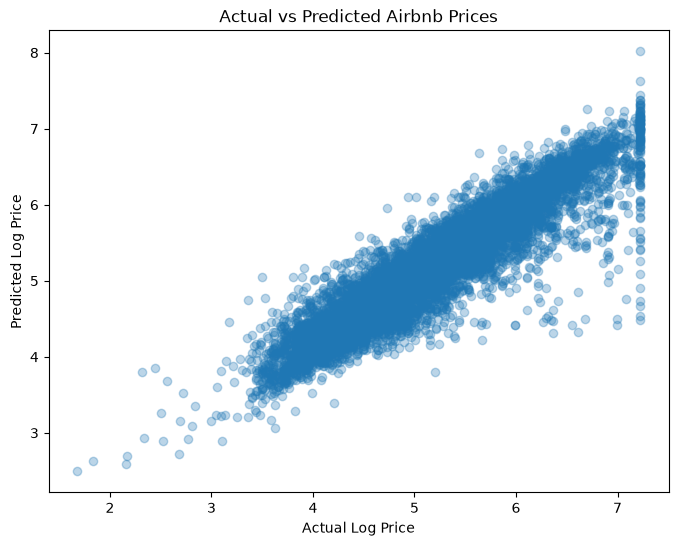

In [54]:
plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    y_pred_gb,
    alpha=0.3
)

plt.xlabel("Actual Log Price")
plt.ylabel("Predicted Log Price")
plt.title("Actual vs Predicted Airbnb Prices")

plt.show()

In [55]:
import joblib

joblib.dump(
    gb_model,
    "../models/gradient_boosting_model.pkl"
)

joblib.dump(
    scaler,
    "../models/scaler.pkl"
)

['../models/scaler.pkl']

In [57]:
import os

# Create processed data folder
os.makedirs("../data/processed", exist_ok=True)

# Save test data
X_test.to_csv("../data/processed/X_test.csv", index=False)
y_test.to_csv("../data/processed/y_test.csv", index=False)

print("Test data saved successfully!")

Test data saved successfully!
